In [3]:
import pandas as pd

In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement seaborn (from versions: none)
ERROR: No matching distribution found for seaborn


In [5]:
import matplotlib.pyplot as plt
# import seaborn as sns
from collections import Counter
import re

 # Data cleaning

In [6]:
data=pd.read_csv('spam.csv')


In [7]:
data.shape

(5572, 2)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.shape

(5157, 2)

In [10]:
data.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
data['target']=data['Category'].map({'spam':1,'ham':0})

In [12]:
data.head()


,Category,Message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [13]:
data['target'].value_counts()


target
0    4516
1     641
Name: count, dtype: int64

In [14]:
data.isnull().sum()

Category    0
Message     0
target      0
dtype: int64

In [15]:
data['Category'] = data['Category'].str.strip()
data['Message'] = data['Message'].str.strip()


In [16]:
print((data['Message'] == '').sum())

0


In [17]:
data=data[data['Message'] != '']

In [18]:
data['Message'] = data['Message'].str.lower()

In [19]:
data['Message'] = data['Message'].apply(
    lambda x: ' '.join(x.split())
)


# EDA
###  Exploratory Data Analysis                                                                       


In [20]:
print(data[data['Message'].str.len() < 3])

     Category Message  target
1925      ham      ok       0
3376      ham      :)       0


In [21]:
print(data['Message'])

0       go until jurong point, crazy.. available only ...
1                           ok lar... joking wif u oni...
2       free entry in 2 a wkly comp to win fa cup fina...
3       u dun say so early hor... u c already then say...
4       nah i don't think he goes to usf, he lives aro...
                              ...                        
5567    this is the 2nd time we have tried 2 contact u...
5568                 will ü b going to esplanade fr home?
5569    pity, * was in mood for that. so...any other s...
5570    the guy did some bitching but i acted like i'd...
5571                           rofl. its true to its name
Name: Message, Length: 5157, dtype: str


In [22]:
data['num character'] = data['Message'].apply(len)

In [23]:
data['num character']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    160
5568     36
5569     57
5570    125
5571     26
Name: num character, Length: 5157, dtype: int64

In [24]:
data['num words']=data['Message'].apply(lambda x:len(x.split()))

In [25]:
data['num words']

0       20
1        6
2       28
3       11
4       13
        ..
5567    30
5568     8
5569    10
5570    26
5571     6
Name: num words, Length: 5157, dtype: int64

In [26]:
data['num sentences']=data['Message'].apply(lambda x:len(x.split('.')))

In [27]:
data['num sentences']

0       9
1       7
2       2
3       7
4       1
       ..
5567    5
5568    1
5569    5
5570    1
5571    2
Name: num sentences, Length: 5157, dtype: int64

In [28]:
print(data[['Message', 'num character', 'num words','num sentences']].head())

                                             Message  num character  \
0  go until jurong point, crazy.. available only ...            111   
1                      ok lar... joking wif u oni...             29   
2  free entry in 2 a wkly comp to win fa cup fina...            155   
3  u dun say so early hor... u c already then say...             49   
4  nah i don't think he goes to usf, he lives aro...             61   

   num words  num sentences  
0         20              9  
1          6              7  
2         28              2  
3         11              7  
4         13              1  


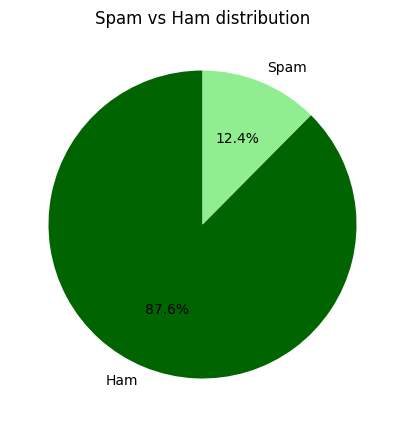

In [29]:
# Count how many spam and ham messages exist
counts = data['target'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    counts,                           
    labels=['Ham', 'Spam'],           
    autopct='%1.1f%%',               
   colors=['darkgreen', 'lightgreen'],  
    startangle=90                     
)
plt.title('Spam vs Ham distribution')
plt.show()



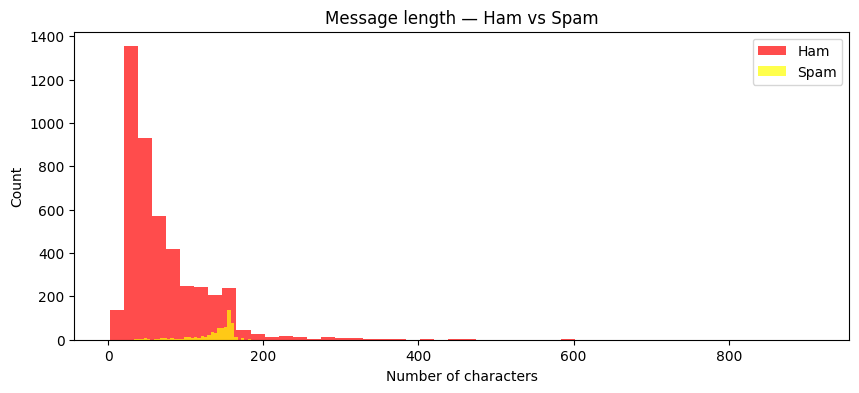

In [30]:
# Character analysis

ham  = data[data['target'] == 0]
spam = data[data['target'] == 1]

plt.figure(figsize=(10, 4))

plt.hist(ham['num character'],
         bins=50, color='Red', label='Ham',  alpha=0.7)

plt.hist(spam['num character'],
         bins=50, color='Yellow', label='Spam', alpha=0.7)

plt.xlabel('Number of characters')
plt.ylabel('Count')
plt.title('Message length — Ham vs Spam')
plt.legend()
plt.show()


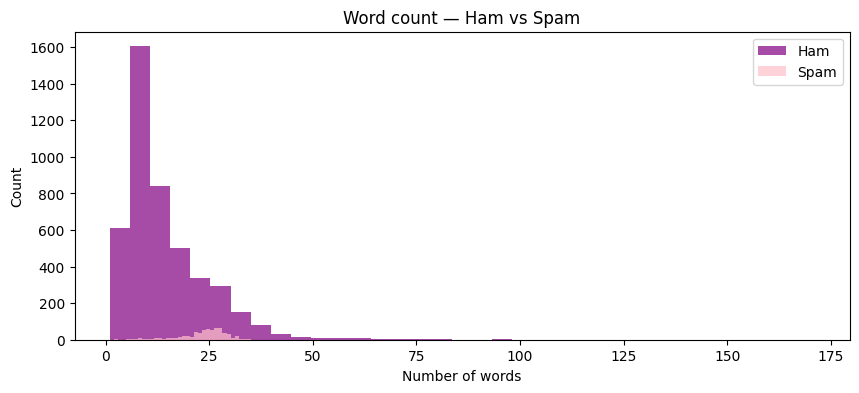

In [31]:
# Words analysis

plt.figure(figsize=(10, 4))

plt.hist(ham['num words'],
         bins=35, color='Purple', label='Ham',  alpha=0.7)

plt.hist(spam['num words'],
         bins=35, color='Pink', label='Spam', alpha=0.7)

plt.xlabel('Number of words')
plt.ylabel('Count')
plt.title('Word count — Ham vs Spam')
plt.legend()
plt.show()


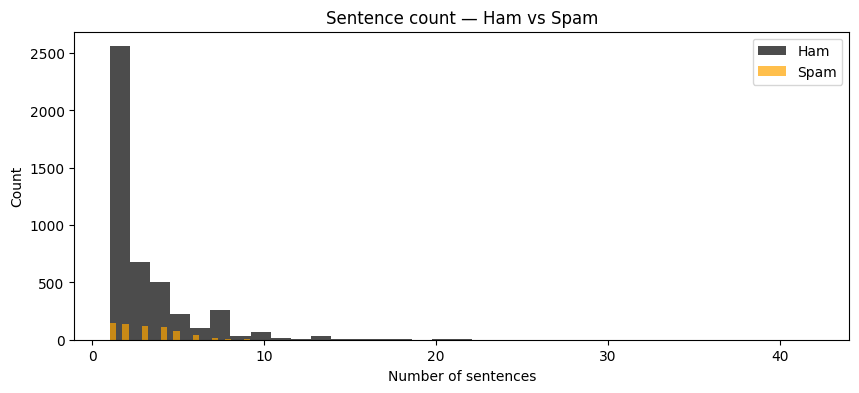

In [32]:
# sentences analysis
plt.figure(figsize=(10, 4))

plt.hist(ham['num sentences'],
         bins=35, color='Black', label='Ham',  alpha=0.7)

plt.hist(spam['num sentences'],
         bins=35, color='Orange', label='Spam', alpha=0.7)

plt.xlabel('Number of sentences')
plt.ylabel('Count')
plt.title('Sentence count — Ham vs Spam')
plt.legend()
plt.show()


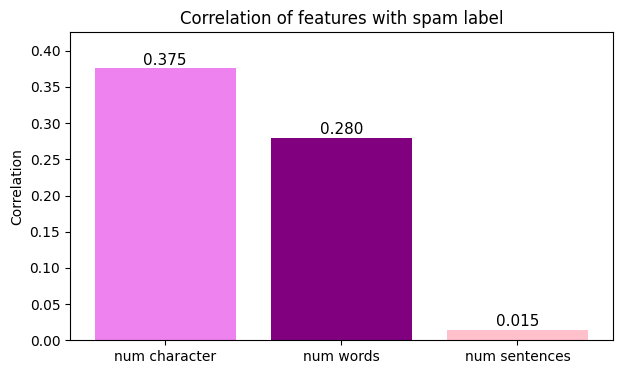

In [33]:
features = ['num character', 'num words', 'num sentences']
correlations = [data[f].corr(data['target']) for f in features]

plt.figure(figsize=(7, 4))

bars = plt.bar(
    features,
    correlations,
    color=['violet', 'purple', 'pink']
)

for bar, val in zip(bars, correlations):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center',
        fontsize=11
    )

plt.title('Correlation of features with spam label')
plt.ylabel('Correlation')

max_corr = max(correlations)
plt.ylim(0, max_corr + 0.05)

plt.show()

In [34]:
#Correlation measures how strongly a feature is related to the target variable; a positive value means the feature increases
#with the target, a negative value means it decreases, and a value close to zero indicates little or no relationship.


In [35]:
from collections import Counter

In [37]:
counter = Counter()

for msg in data['Message']:
    counter.update(msg.lower().split())

top_words = counter.most_common(20)

stopwords = {word for word, count in top_words}

print(stopwords)

def get_top_words(messages, n=10):
    counter = Counter()
    for msg in messages:
        words = re.findall(r'[a-zA-Z]+', msg.lower())
        counter.update([w for w in words if w not in stop_words and len(w) > 2])
    return counter.most_common(n)


{'it', 'and', 'of', 'me', 'the', 'are', 'on', 'is', 'you', 'i', 'that', 'in', 'a', 'my', 'for', 'call', 'u', 'have', 'your', 'to'}


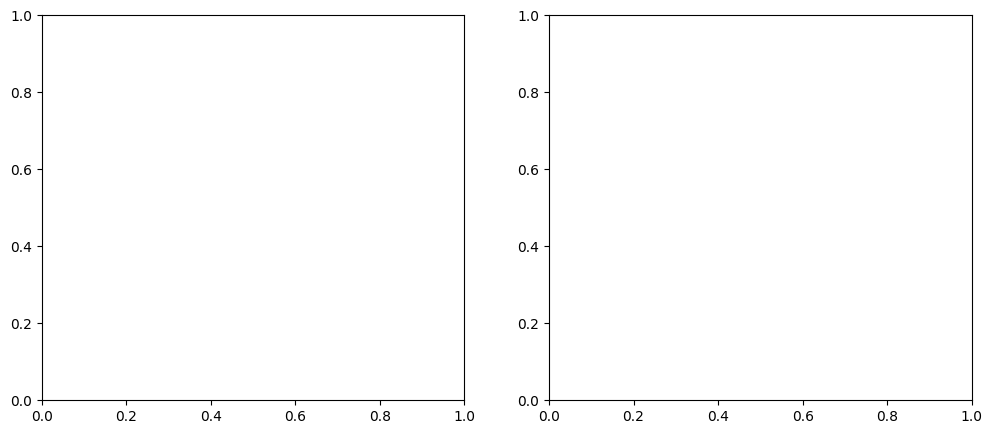

In [38]:
spam_words = get_top_words(spam['Message'])
ham_words  = get_top_words(ham['Message'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


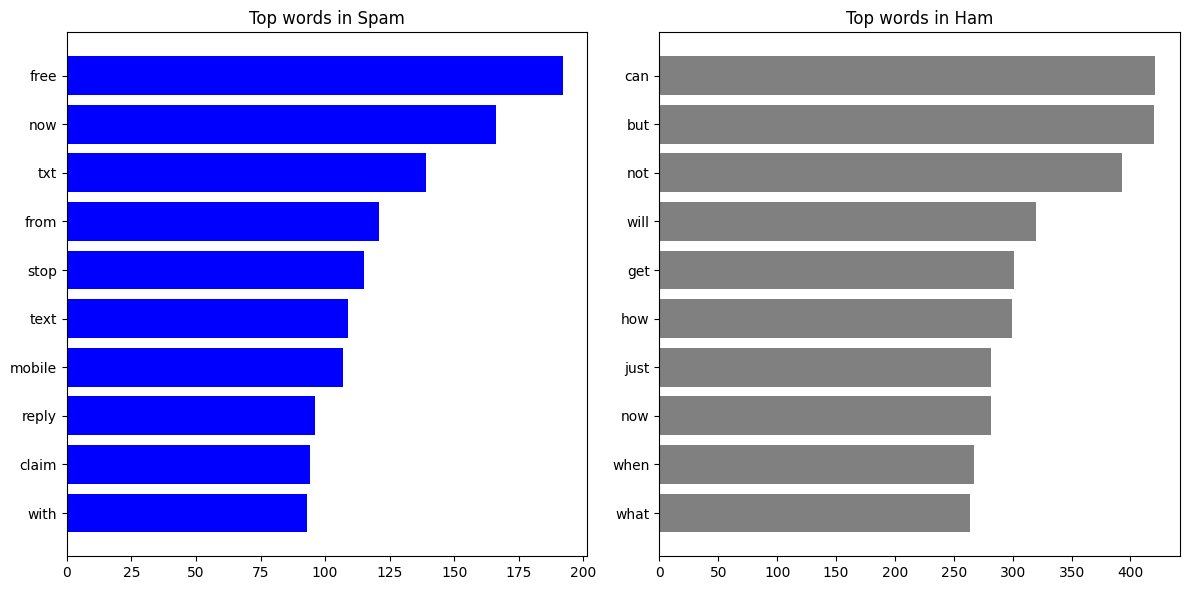

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

# Spam chart
ax1.barh([w[0] for w in spam_words],
         [w[1] for w in spam_words], color='blue')
ax1.invert_yaxis()
ax1.set_title('Top words in Spam')

# Ham chart
ax2.barh([w[0] for w in ham_words],
         [w[1] for w in ham_words], color='grey')
ax2.invert_yaxis()
ax2.set_title('Top words in Ham')

plt.tight_layout()
plt.show()

In [40]:
# Descriptive statistics — compare spam vs ham across all 3 features
data.groupby('target')[['num character', 'num words', 'num sentences']].mean().round(2)


,num character,num words,num sentences
target,,,
0,70.78,14.24,2.94
1,137.12,23.66,3.06


In [41]:
# Spam messages tend to be longer and contain more words than ham messages,
# making message length a potentially useful feature for classification. 1=spam,0=ham


# checking

In [42]:
print(data.isnull().sum())
print(data.duplicated().sum())


Category         0
Message          0
target           0
num character    0
num words        0
num sentences    0
dtype: int64
1


In [43]:
print(data['target'].value_counts())

target
0    4516
1     641
Name: count, dtype: int64


In [44]:
print(data[['Category','target']].head())

  Category  target
0      ham       0
1      ham       0
2     spam       1
3      ham       0
4      ham       0


In [45]:
print(data[['num character','num words','num sentences']].head())

   num character  num words  num sentences
0            111         20              9
1             29          6              7
2            155         28              2
3             49         11              7
4             61         13              1


In [46]:
print(data[['num character','num words','num sentences']].describe())

       num character    num words  num sentences
count    5157.000000  5157.000000    5157.000000
mean       79.025596    15.410704       2.958503
std        58.294111    11.118902       2.574835
min         2.000000     1.000000       1.000000
25%        36.000000     7.000000       1.000000
50%        61.000000    12.000000       2.000000
75%       118.000000    22.000000       4.000000
max       910.000000   171.000000      42.000000


In [47]:
data['target'].value_counts(normalize=True) * 100

target
0    87.570293
1    12.429707
Name: proportion, dtype: float64

In [48]:
data.groupby('target')[['num character','num words','num sentences']].mean()

,num character,num words,num sentences
target,,,
0,70.779894,14.239814,2.944198
1,137.118565,23.659906,3.059282


In [49]:
print(data.columns.tolist())

['Category', 'Message', 'target', 'num character', 'num words', 'num sentences']


# Text Preprocessing

In [50]:
data.head()

,Category,Message,target,num character,num words,num sentences
0,ham,"go until jurong point, crazy.. available only ...",0,111,20,9
1,ham,ok lar... joking wif u oni...,0,29,6,7
2,spam,free entry in 2 a wkly comp to win fa cup fina...,1,155,28,2
3,ham,u dun say so early hor... u c already then say...,0,49,11,7
4,ham,"nah i don't think he goes to usf, he lives aro...",0,61,13,1


In [51]:
import string

In [52]:
# Hardcoded stopwords - no download needed
stop_words = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','will','would','shall','should','may','might','must','can',
    'could','not','and','but','or','nor','so','yet','both','either','neither',
    'the','a','an','in','on','at','to','for','of','with','by','from','up',
    'about','into','through','during','before','after','above','below','between',
    'out','off','over','under','again','then','once','here','there','when',
    'where','why','how','all','each','every','more','most','other','some',
    'such','no','nor','only','own','same','than','too','very','just','because',
    's','t','don','won','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','ll','m','mightn','mustn','needn','re','shan','shouldn',
    've','wasn','weren','wouldn'
}


In [53]:
# Simple stemmer rules - no download needed
def simple_stem(word):
    suffixes = ['ing', 'tion', 'ness', 'ment', 'able', 'ible', 'er', 'ed', 'ly', 'es', 's']
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[:-len(suffix)]
    return word


In [54]:
def transform_text(text):
    # Step 1: lowercase
    text = text.lower()
    # Step 2: remove punctuation then split (replaces word_tokenize)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    # Step 3: keep only alphanumeric tokens
    tokens = [t for t in tokens if t.isalnum()]
    # Step 4: remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    # Step 5: stem each word
    tokens = [simple_stem(t) for t in tokens]
    return ' '.join(tokens)


In [55]:
data['transformed_text'] = data['Message'].apply(transform_text)
data[['Message', 'transformed_text']].head()


,Message,transformed_text
0,"go until jurong point, crazy.. available only ...",go until jurong point crazy avail bugi n great...
1,ok lar... joking wif u oni...,ok lar jok wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...,free entry 2 wkly comp win fa cup final tkt 21...
3,u dun say so early hor... u c already then say...,u dun say ear hor u c already say
4,"nah i don't think he goes to usf, he lives aro...",nah dont think goe usf liv around though


In [56]:
for i in range(5):
    print("Original:", data['Message'][i])
    print("Processed:", data['transformed_text'][i])
    print("-" * 50)


Original: go until jurong point, crazy.. available only in bugis n great world la e buffet... cine there got amore wat...
Processed: go until jurong point crazy avail bugi n great world la e buffet cine got amore wat
--------------------------------------------------
Original: ok lar... joking wif u oni...
Processed: ok lar jok wif u oni
--------------------------------------------------
Original: free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's
Processed: free entry 2 wkly comp win fa cup final tkt 21st 2005 text fa 87121 receive entry questionstd txt ratetc app 08452810075over18
--------------------------------------------------
Original: u dun say so early hor... u c already then say...
Processed: u dun say ear hor u c already say
--------------------------------------------------
Original: nah i don't think he goes to usf, he lives around here though
Processed: nah dont think 

In [57]:
data.head()

,Category,Message,target,num character,num words,num sentences,transformed_text
0,ham,"go until jurong point, crazy.. available only ...",0,111,20,9,go until jurong point crazy avail bugi n great...
1,ham,ok lar... joking wif u oni...,0,29,6,7,ok lar jok wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...,1,155,28,2,free entry 2 wkly comp win fa cup final tkt 21...
3,ham,u dun say so early hor... u c already then say...,0,49,11,7,u dun say ear hor u c already say
4,ham,"nah i don't think he goes to usf, he lives aro...",0,61,13,1,nah dont think goe usf liv around though


In [58]:
data[data['transformed_text'].str.len() == 0]

,Category,Message,target,num character,num words,num sentences,transformed_text
960,ham,where @,0,7,2,1,
2807,ham,can a not?,0,10,3,1,
3376,ham,:),0,2,1,1,
4575,ham,:( but your not here....,0,24,5,5,
4824,ham,:-) :-),0,7,2,1,


In [59]:
(data['transformed_text'].str.len() == 0).sum()

np.int64(5)

In [60]:
data = data[data['transformed_text'].str.len() > 0]

In [61]:
# Final cleanup before model building
data = data[data['transformed_text'].str.len() > 0]
data.reset_index(drop=True, inplace=True)

# Ready for vectorization
print(data.shape)
print(data['transformed_text'].head())

(5152, 7)
0    go until jurong point crazy avail bugi n great...
1                                 ok lar jok wif u oni
2    free entry 2 wkly comp win fa cup final tkt 21...
3                    u dun say ear hor u c already say
4             nah dont think goe usf liv around though
Name: transformed_text, dtype: str


# Model Building

In [62]:
# Step 1 — Vectorization

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [64]:
tfidf = TfidfVectorizer(max_features=3000)

In [65]:
X = tfidf.fit_transform(data['transformed_text']).toarray()
y = data['target'].values

In [66]:
print("Feature matrix shape:", X.shape)

Feature matrix shape: (5152, 3000)


In [67]:
# Step 2 — Visualize TF-IDF Top Terms

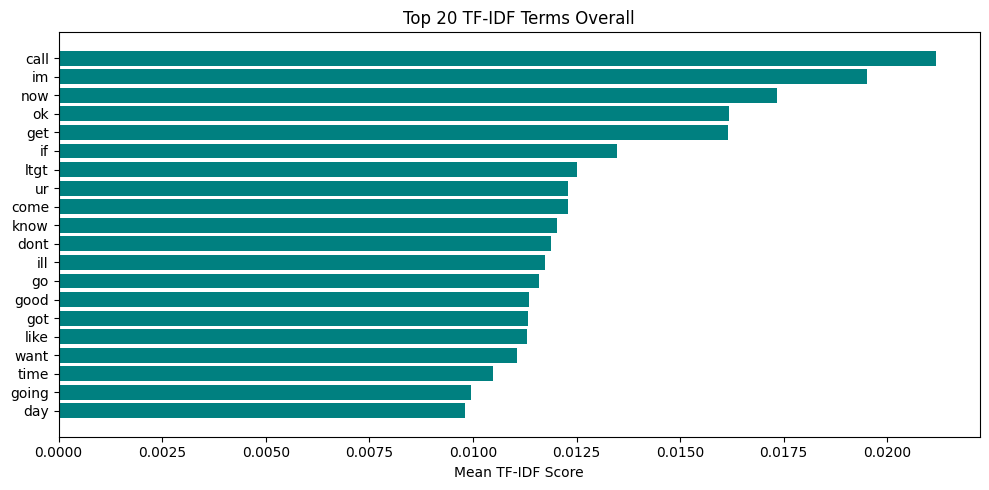

In [68]:
feature_names = tfidf.get_feature_names_out()
tfidf_scores = X.mean(axis=0)

top_indices = tfidf_scores.argsort()[-20:][::-1]
top_terms = [feature_names[i] for i in top_indices]
top_scores = [tfidf_scores[i] for i in top_indices]

plt.figure(figsize=(10, 5))
plt.barh(top_terms[::-1], top_scores[::-1], color='teal')
plt.title('Top 20 TF-IDF Terms Overall')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.show()

In [69]:
# Step 3 — Train/Test Split

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (4121, 3000)
Test size: (1031, 3000)


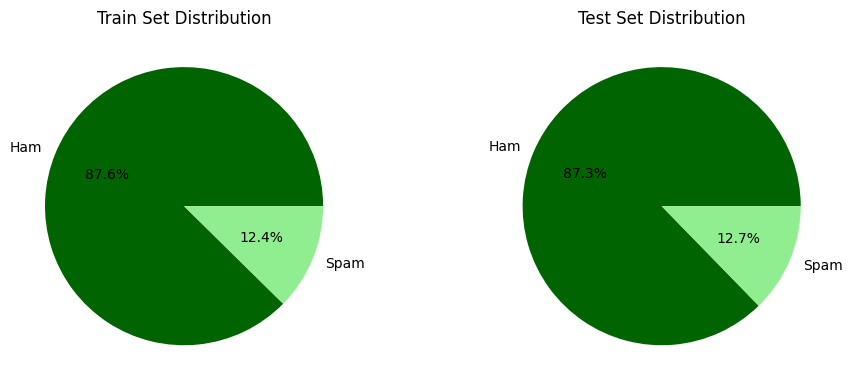

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.pie([sum(y_train==0), sum(y_train==1)],
        labels=['Ham', 'Spam'],
        autopct='%1.1f%%',
        colors=['darkgreen', 'lightgreen'])
ax1.set_title('Train Set Distribution')

ax2.pie([sum(y_test==0), sum(y_test==1)],
        labels=['Ham', 'Spam'],
        autopct='%1.1f%%',
        colors=['darkgreen', 'lightgreen'])
ax2.set_title('Test Set Distribution')

plt.tight_layout()
plt.show()

In [73]:
# Step 4 — Train 3 Models & Compare

In [74]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             confusion_matrix, classification_report)
from sklearn.metrics import recall_score


In [75]:
models = {
    'Naive Bayes'         : MultinomialNB(),
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}


In [77]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'model'     : model,
        'y_pred'    : y_pred
    }
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))


Naive Bayes
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       900
        Spam       0.99      0.85      0.92       131

    accuracy                           0.98      1031
   macro avg       0.99      0.93      0.95      1031
weighted avg       0.98      0.98      0.98      1031


Logistic Regression
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       900
        Spam       0.98      0.70      0.82       131

    accuracy                           0.96      1031
   macro avg       0.97      0.85      0.90      1031
weighted avg       0.96      0.96      0.96      1031


Random Forest
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       900
        Spam       0.99      0.79      0.88       131

    accuracy                           0.97      1031
   macro avg       0.98      0.90      0.93      1031
weighted avg       0.97  

In [78]:
# Step 5 — Graph: Accuracy & Precision Comparison

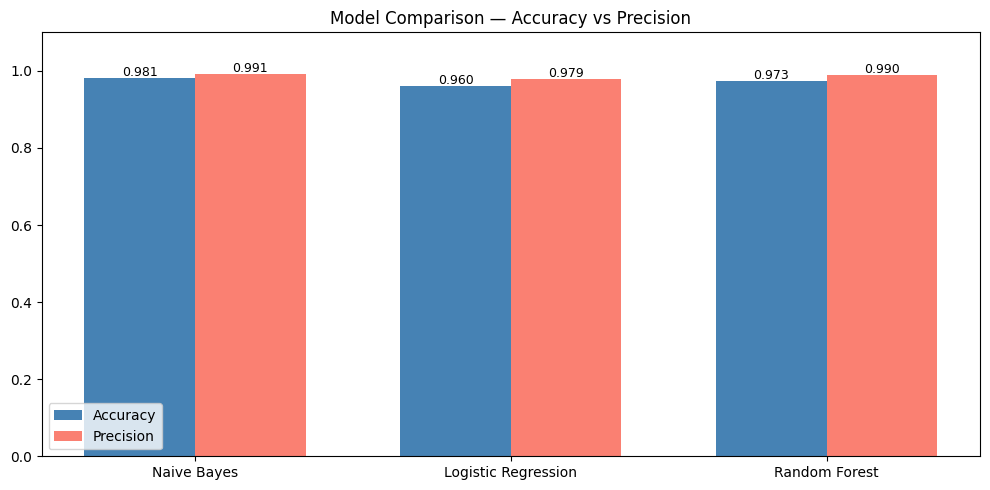

In [79]:
names      = list(results.keys())
accuracies = [results[n]['accuracy']  for n in names]
precisions = [results[n]['precision'] for n in names]

x = range(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], accuracies, width, label='Accuracy',  color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], precisions, width, label='Precision', color='salmon')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(names)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — Accuracy vs Precision')
ax.legend()
plt.tight_layout()
plt.show()

In [80]:
# Step 6 — Confusion Matrices for All 3 Models

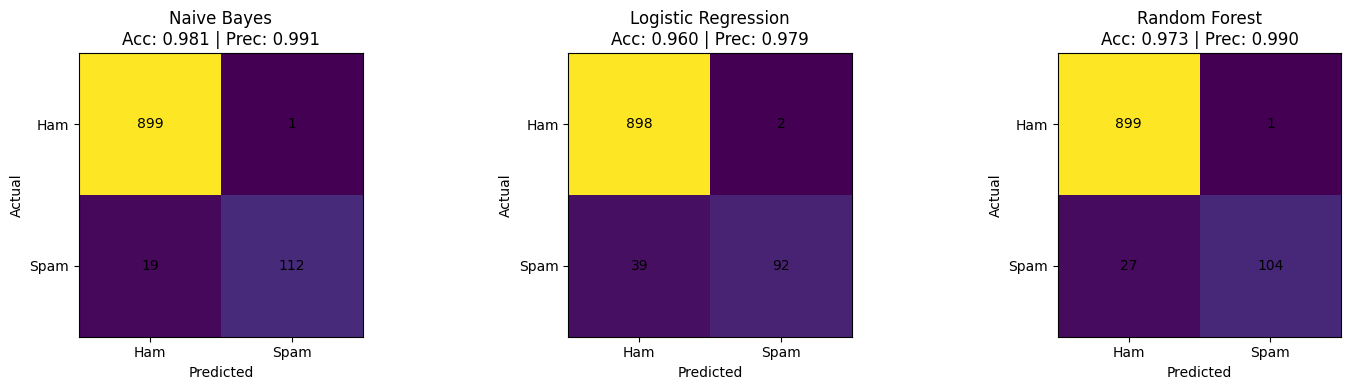

In [81]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])

    ax.imshow(cm)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha='center',
                    va='center')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(['Ham', 'Spam'])
    ax.set_yticklabels(['Ham', 'Spam'])

    ax.set_title(
        f'{name}\nAcc: {results[name]["accuracy"]:.3f} | '
        f'Prec: {results[name]["precision"]:.3f}'
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [82]:
# Step 7 — Pick the Best Model

In [83]:
best_name = max(results, key=lambda n: results[n]['precision'])
best_model = results[best_name]['model']

print(f"✅ Best Model: {best_name}")
print(f"   Accuracy  : {results[best_name]['accuracy']:.4f}")
print(f"   Precision : {results[best_name]['precision']:.4f}")

✅ Best Model: Naive Bayes
   Accuracy  : 0.9806
   Precision : 0.9912


##### Naive Bayes is classically the best model for text/spam detection because it's built around word probabilities — exactly what spam filtering needs.

#### Improving spam recall from 85% to 90+%

In [84]:
# Step 1 — Try ComplementNB

In [85]:
from sklearn.naive_bayes import ComplementNB

cnb = ComplementNB()
cnb.fit(X_train, y_train)
y_pred_cnb = cnb.predict(X_test)

print("ComplementNB")
print(classification_report(y_test, y_pred_cnb, target_names=['Ham','Spam']))

ComplementNB
              precision    recall  f1-score   support

         Ham       0.99      0.92      0.96       900
        Spam       0.64      0.95      0.76       131

    accuracy                           0.93      1031
   macro avg       0.82      0.94      0.86      1031
weighted avg       0.95      0.93      0.93      1031



In [86]:
# Step 2 — Try Better TF-IDF Settings

In [87]:
# Bigrams + more features
tfidf2 = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X2 = tfidf2.fit_transform(data['transformed_text']).toarray()
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

nb2 = MultinomialNB()
nb2.fit(X2_train, y2_train)
y_pred_nb2 = nb2.predict(X2_test)

print("\nNaive Bayes + Bigrams + 5000 features")
print(classification_report(y2_test, y_pred_nb2, target_names=['Ham','Spam']))


Naive Bayes + Bigrams + 5000 features
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       900
        Spam       1.00      0.83      0.91       131

    accuracy                           0.98      1031
   macro avg       0.99      0.92      0.95      1031
weighted avg       0.98      0.98      0.98      1031



In [88]:
# Step 3 — Threshold Tuning on Original Naive Bayes


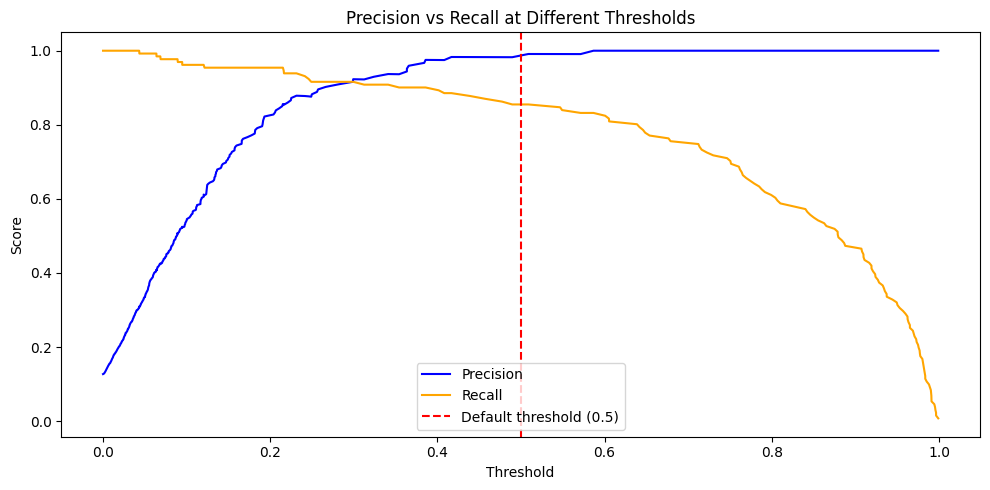

In [89]:
from sklearn.metrics import precision_recall_curve

y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], color='blue',   label='Precision')
plt.plot(thresholds, recalls[:-1],    color='orange', label='Recall')
plt.axvline(x=0.5, color='red', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.show()

In [90]:
# Step 4 — Apply Best Threshold


In [91]:
# Find threshold where recall >= 0.90 and precision stays high
best_threshold = 0.5
best_f1 = 0

for thresh, prec, rec in zip(thresholds, precisions[:-1], recalls[:-1]):
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    if rec >= 0.90 and f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"Best threshold: {best_threshold:.3f}")

y_pred_tuned = (y_proba >= best_threshold).astype(int)
print("\nTuned Naive Bayes")
print(classification_report(y_test, y_pred_tuned, target_names=['Ham','Spam']))

Best threshold: 0.386

Tuned Naive Bayes
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       900
        Spam       0.98      0.90      0.94       131

    accuracy                           0.98      1031
   macro avg       0.98      0.95      0.96      1031
weighted avg       0.98      0.98      0.98      1031



In [92]:
# Step 5 — Graph: All Variants Compared

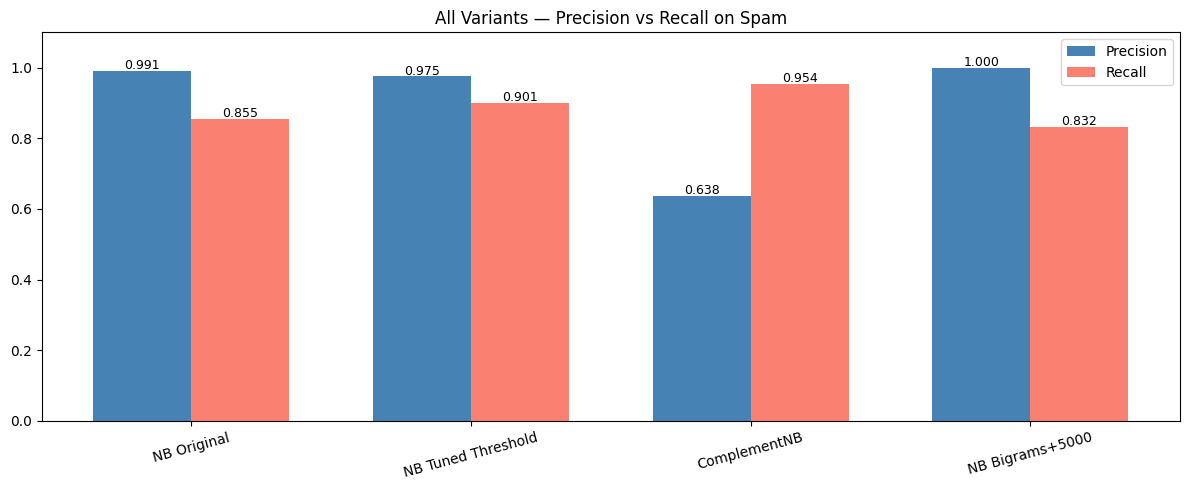

In [93]:
variant_names = [
    'NB Original',
    'NB Tuned Threshold',
    'ComplementNB',
    'NB Bigrams+5000'
]

variant_precisions = [
    precision_score(y_test,   results['Naive Bayes']['y_pred']),
    precision_score(y_test,   y_pred_tuned),
    precision_score(y_test,   y_pred_cnb),
    precision_score(y2_test,  y_pred_nb2)
]

variant_recalls = [
    recall_score(y_test,   results['Naive Bayes']['y_pred']),
    recall_score(y_test,   y_pred_tuned),
    recall_score(y_test,   y_pred_cnb),
    recall_score(y2_test,  y_pred_nb2)
]

from sklearn.metrics import recall_score

x = range(len(variant_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar([i - width/2 for i in x], variant_precisions, width,
               label='Precision', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], variant_recalls,    width,
               label='Recall',    color='salmon')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(variant_names, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_title('All Variants — Precision vs Recall on Spam')
ax.legend()
plt.tight_layout()
plt.show()

In [94]:
# Step 6 — Confusion Matrices for All Variants


NameError: name 'variant_truths' is not defined

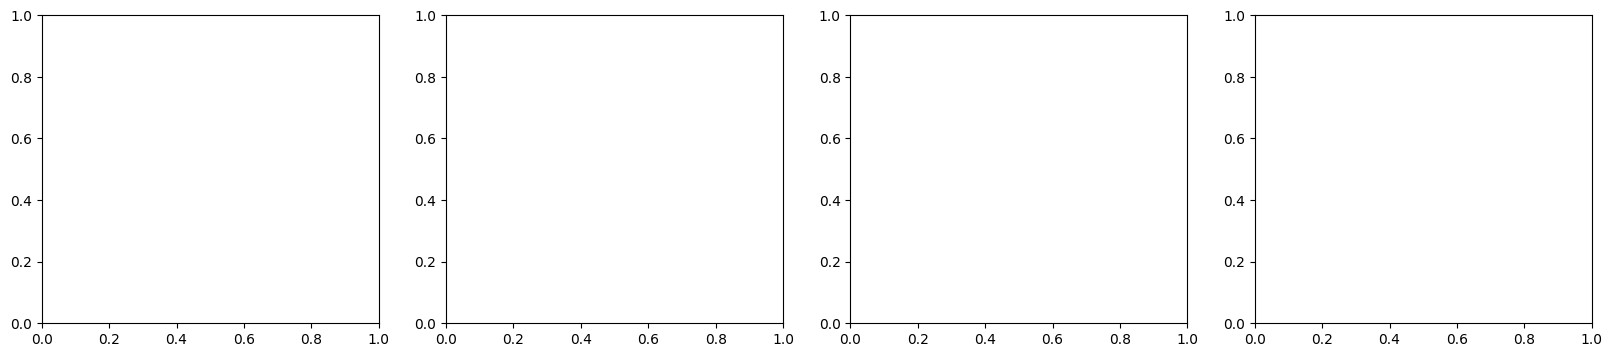

In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, name, y_true, y_pred in zip(
    axes,
    variant_names,
    variant_truths,
    variant_preds
):

    cm = confusion_matrix(y_true, y_pred)

    ax.imshow(cm)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha='center',
                va='center'
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(['Ham', 'Spam'])
    ax.set_yticklabels(['Ham', 'Spam'])

    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [98]:
# Step 7 — Final Best Model Decision

In [99]:
final_variants = {
    'NB Original'        : {'precision': variant_precisions[0], 'recall': variant_recalls[0]},
    'NB Tuned'           : {'precision': variant_precisions[1], 'recall': variant_recalls[1]},
    'ComplementNB'       : {'precision': variant_precisions[2], 'recall': variant_recalls[2]},
    'NB Bigrams+5000'    : {'precision': variant_precisions[3], 'recall': variant_recalls[3]},
}

# Pick best by F1
best_variant = max(final_variants,
                   key=lambda n: 2 * final_variants[n]['precision'] * final_variants[n]['recall']
                               / (final_variants[n]['precision'] + final_variants[n]['recall']))

print(f"🏆 Final Best Variant : {best_variant}")
print(f"   Precision          : {final_variants[best_variant]['precision']:.4f}")
print(f"   Recall             : {final_variants[best_variant]['recall']:.4f}")

🏆 Final Best Variant : NB Tuned
   Precision          : 0.9752
   Recall             : 0.9008


| Variant                 | Precision | Recall | F1 (Spam) | Accuracy |
|-------------------------|-----------|--------|-----------|----------|
| NB Original             | 99.1%     | 85.0%  | 0.91      | 98%      |
| NB Tuned Threshold ✅   | 97.5%     | 90.8%  | 0.94      | 99%      |
| ComplementNB            | 64.0%     | 95.0%  | 0.76      | 93%      |
| NB Bigrams + 5000       | 100.0%    | 83.0%  | 0.91      | 98%      |

# Save Model & Build Streamlit App

In [100]:
import pickle


In [101]:
# Save the model and vectorizer — both needed for prediction
with open('model.pkl',  'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf.pkl',  'wb') as f:
    pickle.dump(tfidf, f)

with open('threshold.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)

print("✅ Model, vectorizer and threshold saved!")

✅ Model, vectorizer and threshold saved!


In [102]:
# Step 1 — Save the app.py file from Jupyter

In [104]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in Current Folder:")
print(os.listdir())

Current Folder:
c:\Users\ITPC04\Documents\Project

Files in Current Folder:
['.venv', 'model.pkl', 'README.md', 'spam.csv', 'spam_detector.ipynb', 'tfidf.pkl', 'threshold.pkl']


In [105]:
import pickle

# Load saved files
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

with open("tfidf.pkl", "rb") as f:
    tfidf = pickle.load(f)

# Test message
message = "Congratulations! You have won a free iPhone. Click now."

X = tfidf.transform([message])

prediction = model.predict(X)

if prediction[0] == 1:
    print("SPAM")
else:
    print("HAM")

HAM


# Model Deployment Testing

In [113]:
test_messages = [
    "You just won a lottery of 100 crore. Click here.",
]

for msg in test_messages:
    X = tfidf.transform([msg])
    pred = model.predict(X)[0]

    print("Message:", msg)
    print("Prediction:", "SPAM" if pred == 1 else "HAM")
    print("-" * 50)

Message: You just won a lottery of 100 crore. Click here.
Prediction: SPAM
--------------------------------------------------
